In [1]:
!git clone -b Lab_3 https://github.com/Vasilisa-Kozlovskaya/SANS_itmo.git

Cloning into 'SANS_itmo'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 265 (delta 18), reused 34 (delta 9), pack-reused 183 (from 1)
Receiving objects: 100% (265/265), 4.85 MiB | 6.28 MiB/s, done.
Resolving deltas: 100% (109/109), done.


In [2]:
import os
os.chdir('/content/SANS_itmo')

!ls

configs  README.md  requirements.txt  SANS_2.ipynb  SANS_3.ipynb  src  training


In [3]:
# @title
!git pull origin Lab_2_main

From https://github.com/Vasilisa-Kozlovskaya/SANS_itmo
 * branch            Lab_2_main -> FETCH_HEAD
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.


In [5]:
import torch
from src.backend.flash_attention import flash_attention_fwd

# --- ЭТАЛОННАЯ РЕАЛИЗАЦИЯ НА PYTORCH ---
def torch_causal_attention(q, k, v, sm_scale=None):
    if sm_scale is None:
        sm_scale = 1.0 / (q.shape[-1] ** 0.5)

    # Обычное перемножение: (B, H, N, d) x (B, H, d, N) -> (B, H, N, N)
    scores = torch.matmul(q, k.transpose(-2, -1)) * sm_scale

    # Создание каузальной маски (нижнетреугольная матрица)
    N = q.shape[-2]
    mask = torch.tril(torch.ones((N, N), device=q.device)).bool()

    # Заполнение верхнего треугольника минус бесконечностью
    scores = scores.masked_fill(~mask, float('-inf'))

    # Стандартный Softmax и взвешивание значений V
    attn_weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, v)
    return output

# --- ТЕСТ СРАВНЕНИЯ (Пункт 3.1 методички) ---
def run_verification_test():
    # Настройки устройства (Triton работает только на CUDA)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        print("Внимание: Triton требует наличия GPU!")
        return
    dtype = torch.float16
    # Задаем размерности (можно приблизить к параметрам твоей GPT из чекпоинта)
    BATCH_SIZE = 4
    NUM_HEADS = 8
    SEQ_LEN = 1024
    HEAD_DIM = 64  # Должен совпадать с BLOCK_DMIN в кернеле

    print(dtype)
    print(f"Генерация тестовых данных: Batch={BATCH_SIZE}, Heads={NUM_HEADS}, SeqLen={SEQ_LEN}, Dim={HEAD_DIM}")

    # Triton-кернелы для матричного умножения критичны к полуточному формату (float16/bfloat16)
    q = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16)
    k = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16)
    v = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16)

    # 1. Запуск эталона PyTorch
    torch_out = torch_causal_attention(q, k, v)

    # 2. Запуск твоего кастомного Triton-кернела
    # (Если запускаешь прямо в ячейке Colab, убедись, что код кернела из Шага 1 выполнен выше)
    triton_out = flash_attention_fwd(q, k, v)

    # 3. Сравнение результатов
    try:
        # Для половинной точности (float16) ставим чуть более мягкие допуски аtol/rtol из-за специфики округлений в Triton
        torch.testing.assert_close(triton_out, torch_out, atol=1e-3, rtol=1e-3)
        print("🎉 Успех! Выходы твоей реализации совпали с PyTorch в пределах погрешности float16.")
    except AssertionError as e:
        print("❌ Ошибка валидации! Выходы различаются:")
        print(e)

# Запуск проверки
run_verification_test()

ImportError: cannot import name 'flash_attention_fwd' from 'src.backend.flash_attention' (/content/SANS_itmo/src/backend/flash_attention.py)

In [6]:
from src.backend.flash_attention import FlashCausalAttention

In [7]:
import torch

# --- ЭТАЛОННАЯ РЕАЛИЗАЦИЯ НА PYTORCH С ПОДДЕРЖКОЙ АВТОГРАДА ---
def torch_causal_attention_reference(q, k, v, sm_scale=None):
    if sm_scale is None:
        sm_scale = 1.0 / (q.shape[-1] ** 0.5)

    scores = torch.matmul(q, k.transpose(-2, -1)) * sm_scale
    N = q.shape[-2]
    mask = torch.tril(torch.ones((N, N), device=q.device)).bool()
    scores = scores.masked_fill(~mask, float('-inf'))

    attn_weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, v)
    return output

# --- ВЕРИФИКАЦИОННЫЙ ТЕСТ BACKWARD (Задание 3.2 методички) ---
def run_backward_verification():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type != "cuda":
        print("Ошибка: Triton требует GPU (CUDA) для вычислений!")
        return

    # Настройки размерностей
    BATCH_SIZE = 2
    NUM_HEADS = 4
    SEQ_LEN = 512
    HEAD_DIM = 64

    print(f"🚀 Запуск проверки градиентов для маскированного FlashAttention...")

    # Инициализируем тензоры и включаем отслеживание градиентов (requires_grad=True)
    q_torch = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    k_torch = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    v_torch = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)

    # Клонируем данные для Тритона, чтобы обеспечить 100% идентичность начальных точек
    q_triton = q_torch.detach().clone().requires_grad_(True)
    k_triton = k_torch.detach().clone().requires_grad_(True)
    v_triton = v_torch.detach().clone().requires_grad_(True)

    # Случайный внешний градиент dO (upstream gradient) для симуляции обратного прохода
    do = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16)

    # 1. Шаг Нативного PyTorch
    out_torch = torch_causal_attention_reference(q_torch, k_torch, v_torch)
    out_torch.backward(do) # Считаем эталонные градиенты

    # 2. Шаг твоего Кастомного Triton-модуля
    # (Перед запуском убедись, что класс FlashCausalAttention объявлен в ячейке выше)
    flash_attn_layer = FlashCausalAttention()
    out_triton = flash_attn_layer(q_triton, k_triton, v_triton)
    out_triton.backward(do) # Считаем тритон градиенты

    # 3. Сравнение результатов через assert_close (требование задания)
    print("\nПроверка результатов:")
    try:
        # Проверяем совпадение выходов прямого шага (Forward)
        torch.testing.assert_close(out_triton, out_torch, atol=1e-3, rtol=1e-3)
        print("  ✅ Шаг FORWARD: Успешно пройден!")

        # Проверяем совпадение градиентов по Query (dQ)
        torch.testing.assert_close(q_triton.grad, q_torch.grad, atol=1e-2, rtol=1e-2)
        print("  ✅ Шаг BACKWARD (градиент dQ): Успешно совпал!")

        # Проверяем совпадение градиентов по Keys (dK)
        torch.testing.assert_close(k_triton.grad, k_torch.grad, atol=1e-2, rtol=1e-2)
        print("  ✅ Шаг BACKWARD (градиент dK): Успешно совпал!")

        # Проверяем совпадение градиентов по Values (dV)
        torch.testing.assert_close(v_triton.grad, v_torch.grad, atol=1e-2, rtol=1e-2)
        print("  ✅ Шаг BACKWARD (градиент dV): Успешно совпал!")

        print("\n🎉 ИТОГ: Задание 3.2 успешно выполнено! Твой кастомный Backward-кернел математически эквивалентен PyTorch.")

    except AssertionError as e:
        print("\n❌ Ошибка несовпадения расчетов:")
        print(e)

# Запускаем тест в ячейке ноутбука
run_backward_verification()

🚀 Запуск проверки градиентов для маскированного FlashAttention...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



Проверка результатов:
  ✅ Шаг FORWARD: Успешно пройден!
  ✅ Шаг BACKWARD (градиент dQ): Успешно совпал!
  ✅ Шаг BACKWARD (градиент dK): Успешно совпал!
  ✅ Шаг BACKWARD (градиент dV): Успешно совпал!

🎉 ИТОГ: Задание 3.2 успешно выполнено! Твой кастомный Backward-кернел математически эквивалентен PyTorch.


In [8]:
from src.backend.bench_utils import compute_causal_attention_flops

=== 📊 Запуск бенчмарка для шага FORWARD ===


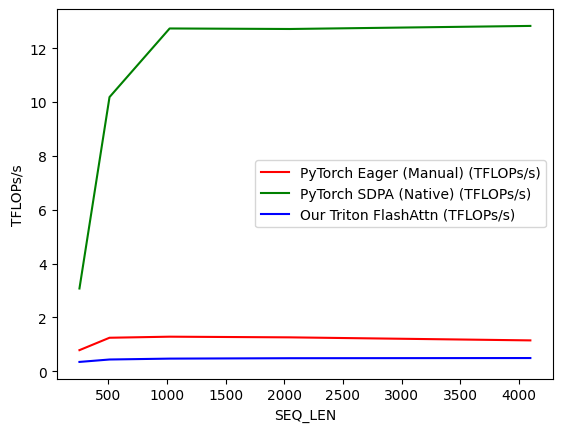

flash-attention-fwd-performance:
   SEQ_LEN  PyTorch Eager (Manual) (TFLOPs/s)  PyTorch SDPA (Native) (TFLOPs/s)  Our Triton FlashAttn (TFLOPs/s)
0    256.0                           0.780285                          3.071198                         0.342689
1    512.0                           1.240998                         10.184339                         0.432641
2   1024.0                           1.280477                         12.735027                         0.465396
3   2048.0                           1.255676                         12.715307                         0.480670
4   4096.0                           1.142936                         12.829417                         0.486962

=== 📊 Запуск бенчмарка для шага BACKWARD ===


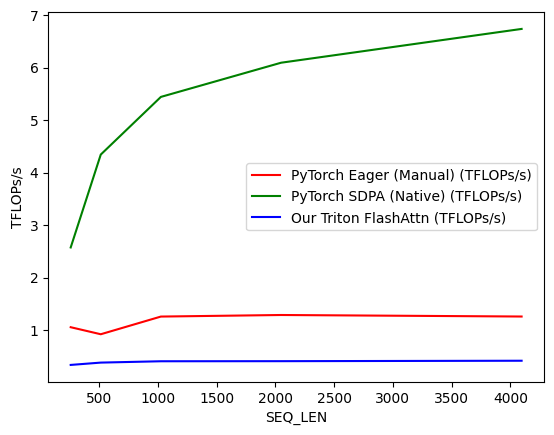

flash-attention-bwd-performance:
   SEQ_LEN  PyTorch Eager (Manual) (TFLOPs/s)  PyTorch SDPA (Native) (TFLOPs/s)  Our Triton FlashAttn (TFLOPs/s)
0    256.0                           1.053123                          2.573617                         0.334056
1    512.0                           0.918892                          4.344553                         0.378370
2   1024.0                           1.256057                          5.444015                         0.403922
3   2048.0                           1.285877                          6.096054                         0.405536
4   4096.0                           1.256834                          6.740285                         0.413902


In [9]:
import torch
import triton
import triton.testing

# Шаблон фиксированных параметров (батч, головы, размерность хэда)
# соотносится с вашим configs.yaml
CONFIG_ARGS = {'BATCH_SIZE': 4, 'NUM_HEADS': 8, 'HEAD_DIM': 64}

# ==========================================
# 1. БЕНЧМАРК ДЛЯ ВПЕРЕД (FORWARD PASS)
# ==========================================
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['SEQ_LEN'],
        x_vals=[256, 512, 1024, 2048, 4096],
        x_log=False,
        line_arg='provider',
        line_vals=['pytorch-eager', 'pytorch-sdpa', 'triton-flash-attn'],
        line_names=['PyTorch Eager (Manual)', 'PyTorch SDPA (Native)', 'Our Triton FlashAttn'],
        styles=[('red', '-'), ('green', '-'), ('blue', '-')],
        ylabel='TFLOPs/s',
        plot_name='flash-attention-fwd-performance',
        args=CONFIG_ARGS
    )
)
def bench_flash_attention_fwd(SEQ_LEN, provider, BATCH_SIZE, NUM_HEADS, HEAD_DIM):
    device = torch.device("cuda")
    q = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    k = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    v = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)

    custom_flash_layer = FlashCausalAttention()

    if provider == 'pytorch-eager':
        fn = lambda: torch_causal_attention_reference(q, k, v)
    elif provider == 'pytorch-sdpa':
        fn = lambda: torch.nn.functional.scaled_dot_product_attention(q, k, v, is_causal=True)
    elif provider == 'triton-flash-attn':
        fn = lambda: custom_flash_layer(q, k, v)

    # Замеряем ТОЛЬКО прямой проход
    ms = triton.testing.do_bench(fn, warmup=25, rep=100)

    flops = compute_causal_attention_flops(BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM, mode="forward")
    return (flops / ms) * 1e-9


# ==========================================
# 2. БЕНЧМАРК ДЛЯ НАЗАД (BACKWARD PASS)
# ==========================================
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['SEQ_LEN'],
        x_vals=[256, 512, 1024, 2048, 4096],
        x_log=False,
        line_arg='provider',
        line_vals=['pytorch-eager', 'pytorch-sdpa', 'triton-flash-attn'],
        line_names=['PyTorch Eager (Manual)', 'PyTorch SDPA (Native)', 'Our Triton FlashAttn'],
        styles=[('red', '-'), ('green', '-'), ('blue', '-')],
        ylabel='TFLOPs/s',
        plot_name='flash-attention-bwd-performance',
        args=CONFIG_ARGS
    )
)
def bench_flash_attention_bwd(SEQ_LEN, provider, BATCH_SIZE, NUM_HEADS, HEAD_DIM):
    device = torch.device("cuda")
    q = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    k = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    v = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16, requires_grad=True)
    do = torch.randn((BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM), device=device, dtype=torch.float16)

    custom_flash_layer = FlashCausalAttention()

    if provider == 'pytorch-eager':
        fn = lambda: torch_causal_attention_reference(q, k, v)
    elif provider == 'pytorch-sdpa':
        fn = lambda: torch.nn.functional.scaled_dot_product_attention(q, k, v, is_causal=True)
    elif provider == 'triton-flash-attn':
        fn = lambda: custom_flash_layer(q, k, v)

    # Функция полного прохода для вычисления градиентов
    def run_full_pass():
        if q.grad is not None: q.grad.zero_()
        if k.grad is not None: k.grad.zero_()
        if v.grad is not None: v.grad.zero_()
        out = fn()
        out.backward(do, retain_graph=True)

    # Замеряем связку fwd + bwd
    ms = triton.testing.do_bench(run_full_pass, warmup=25, rep=100)

    flops = compute_causal_attention_flops(BATCH_SIZE, NUM_HEADS, SEQ_LEN, HEAD_DIM, mode="backward")
    return (flops / ms) * 1e-9


# ==========================================
# 3. ЗАПУСК ОБОИХ ЭКСПЕРИМЕНТОВ
# ==========================================
def run_all_benchmarks():
    if not torch.cuda.is_available():
        print("Тестирование невозможно: требуется GPU ускоритель.")
        return

    print("=== 📊 Запуск бенчмарка для шага FORWARD ===")
    bench_flash_attention_fwd.run(show_plots=True, print_data=True)

    print("\n=== 📊 Запуск бенчмарка для шага BACKWARD ===")
    bench_flash_attention_bwd.run(show_plots=True, print_data=True)

run_all_benchmarks()

=== 🧠 Запуск профилирования памяти (Forward Pass) ===
Профилирование для SEQ_LEN = 256...
Профилирование для SEQ_LEN = 512...
Профилирование для SEQ_LEN = 1024...
Профилирование для SEQ_LEN = 2048...
Профилирование для SEQ_LEN = 4096...


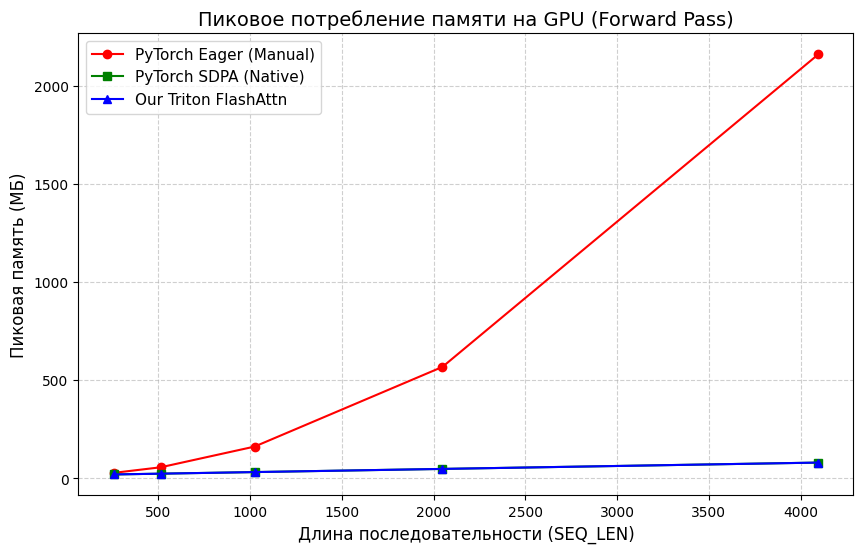

In [10]:
import torch
import gc
import matplotlib.pyplot as plt

def profile_memory_usage(seq_lens, batch_size=4, num_heads=8, head_dim=64):
    device = torch.device("cuda")

    # Списки для сохранения результатов (в Мегабайтах)
    mem_eager_fwd = []
    mem_sdpa_fwd = []
    mem_triton_fwd = []

    custom_flash_layer = FlashCausalAttention()

    print("=== 🧠 Запуск профилирования памяти (Forward Pass) ===")

    for N in seq_lens:
        print(f"Профилирование для SEQ_LEN = {N}...")

        # --- 1. PYTORCH EAGER ---
        # Очищаем кэш перед замером
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

        q = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)
        k = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)
        v = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)

        # Замер пика памяти во время выполнения функции
        out_eager = torch_causal_attention_reference(q, k, v)
        peak_eager = torch.cuda.max_memory_allocated(device) / (1024 ** 2) # Переводим в МБ
        mem_eager_fwd.append(peak_eager)

        del q, k, v, out_eager

        # --- 2. PYTORCH SDPA ---
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

        q = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)
        k = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)
        v = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)

        out_sdpa = torch.nn.functional.scaled_dot_product_attention(q, k, v, is_causal=True)
        peak_sdpa = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        mem_sdpa_fwd.append(peak_sdpa)

        del q, k, v, out_sdpa

        # --- 3. OUR TRITON FLASHATTENTION ---
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)

        q = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)
        k = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)
        v = torch.randn((batch_size, num_heads, N, head_dim), device=device, dtype=torch.float16, requires_grad=True)

        out_triton = custom_flash_layer(q, k, v)
        peak_triton = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        mem_triton_fwd.append(peak_triton)

        del q, k, v, out_triton

    # --- СТРОИМ ГРАФИК ---
    plt.figure(figsize=(10, 6))
    plt.plot(seq_lens, mem_eager_fwd, label="PyTorch Eager (Manual)", color="red", marker="o", linestyle="-")
    plt.plot(seq_lens, mem_sdpa_fwd, label="PyTorch SDPA (Native)", color="green", marker="s", linestyle="-")
    plt.plot(seq_lens, mem_triton_fwd, label="Our Triton FlashAttn", color="blue", marker="^", linestyle="-")

    plt.title("Пиковое потребление памяти на GPU (Forward Pass)", fontsize=14)
    plt.xlabel("Длина последовательности (SEQ_LEN)", fontsize=12)
    plt.ylabel("Пиковая память (МБ)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=11)
    plt.show()

# Запуск профайлера памяти для тех же длин контекста
SEQ_LENS = [256, 512, 1024, 2048, 4096]
profile_memory_usage(SEQ_LENS)